
# DINO Tapenade Adjoint Analysis


## Loading the Data

In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import xmitgcm
import matplotlib.pyplot as plt

import warnings; warnings.filterwarnings("ignore")

In [2]:
## analyze a sample run directory

run_dir = "/scratch2/tshahriar/DINO_MITgcm_v011526_tapAdj_runs/from50yPickup_noProfile_DINO_MITgcm_v011526_tapAdj_mpi_30d_run24926/"

In [3]:
adxx_vars = {
    # 3D controls
    'adxx_theta': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'adxx_theta',
            'long_name': 'Sensitivity to Initial Potential Temperature',
            'units': 'dJ/degC'
        }
    },

    'adxx_salt': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'adxx_salt',
            'long_name': 'Sensitivity to Initial Salinity',
            'units': 'dJ/(g/kg)'
        }
    },

    'adxx_diffkr': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'adxx_diffkr',
            'long_name': 'Sensitivity to Vertical Diffusivity',
            'units': 'dJ/(m^2/s)'
        }
    },

    # 2D time-dependent controls

    'adxx_qnet': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_qnet',
            'long_name': 'Sensitivity to Net Surface Heat Flux',
            'units': 'dJ/(W/m^2)'
        }
    },

    'adxx_qsw': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_qsw',
            'long_name': 'Sensitivity to Shortwave Radiation Flux',
            'units': 'dJ/(W/m^2)'
        }
    },

    'adxx_empmr': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_empmr',
            'long_name': 'Sensitivity to Freshwater Flux (E−P−R)',
            'units': 'dJ/(kg/m^2/s)'
        }
    },

    'adxx_fu': {
        'dims': ['j', 'i_g'],
        'attrs': {
            'standard_name': 'adxx_fu',
            'long_name': 'Sensitivity to Zonal Momentum Forcing',
            'units': 'dJ/(m/s^2)'
        }
    },

    'adxx_fv': {
        'dims': ['j_g', 'i'],
        'attrs': {
            'standard_name': 'adxx_fv',
            'long_name': 'Sensitivity to Meridional Momentum Forcing',
            'units': 'dJ/(m/s^2)'
        }
    }
}

In [4]:
adj_vars = {
    # 3D adjoint variables
    'ADJtheta': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'ADJtheta',
            'long_name': 'Adjoint Sensitivity to Potential Temperature',
            'units': 'dJ/degC'
        }
    },

    'ADJsalt': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'ADJsalt',
            'long_name': 'Adjoint Sensitivity to Salinity',
            'units': 'dJ/(g/kg)'
        }
    },

    'ADJdiffkr': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'ADJdiffkr',
            'long_name': 'Adjoint Sensitivity to Vertical Diffusivity',
            'units': 'dJ/(m^2/s)'
        }
    },

    # 2D surface momentum adjoint
    'ADJtaux': {
        'dims': ['j', 'i_g'],
        'attrs': {
            'standard_name': 'ADJtaux',
            'long_name': 'Adjoint Sensitivity to Zonal Surface Wind Stress',
            'units': 'dJ/(N/m^2)'
        }
    },

    'ADJtauy': {
        'dims': ['j_g', 'i'],
        'attrs': {
            'standard_name': 'ADJtauy',
            'long_name': 'Adjoint Sensitivity to Meridional Surface Wind Stress',
            'units': 'dJ/(N/m^2)'
        }
    },

    # 2D surface flux adjoints
    'ADJqnet': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'ADJqnet',
            'long_name': 'Adjoint Sensitivity to Net Surface Heat Flux',
            'units': 'dJ/(W/m^2)'
        }
    },

    'ADJqsw': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'ADJqsw',
            'long_name': 'Adjoint Sensitivity to Shortwave Radiation Flux',
            'units': 'dJ/(W/m^2)'
        }
    },

    'ADJempmr': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'ADJempmr',
            'long_name': 'Adjoint Sensitivity to Freshwater Flux (E−P−R)',
            'units': 'dJ/(kg/m^2/s)'
        }
    }
}

In [5]:
adxx_prefix = ['adxx_theta','adxx_salt','adxx_diffkr','adxx_fu','adxx_fv','adxx_qnet','adxx_qsw','adxx_empmr']

adj_prefix = ['ADJtheta','ADJsalt','ADJdiffkr','ADJtaux','ADJtauy', 'ADJqnet','ADJqsw','ADJempmr']

In [6]:
ds_adxx = xmitgcm.open_mdsdataset(
    run_dir,
    grid_dir=run_dir,
    prefix=adxx_prefix,
    ref_date=np.datetime64("2000-01-01T00:00:00"),
    delta_t=1800,
    extra_variables=adxx_vars
)         

In [7]:
ds_adj = xmitgcm.open_mdsdataset(
    run_dir,
    grid_dir=run_dir,
    prefix=adj_prefix,
    ref_date=np.datetime64("2000-01-01T00:00:00"),
    delta_t=1800,
    extra_variables=adj_vars
)

In [8]:
ds_adxx

<xarray.Dataset>
Dimensions:      (time: 1, XC: 51, YC: 198, XG: 51, YG: 198, Z: 36, Zp1: 37,
                  Zu: 36, Zl: 36)
Coordinates: (12/37)
    iter         (time) int64 0
  * time         (time) datetime64[ns] 2000-01-01
  * XC           (XC) >f4 -50.5 -49.5 -48.5 -47.5 -46.5 ... -3.5 -2.5 -1.5 -0.5
  * YC           (YC) >f4 -69.85 -69.5 -69.15 -68.79 ... 68.43 68.79 69.15 69.5
  * XG           (XG) >f4 -50.0 -49.0 -48.0 -47.0 -46.0 ... -3.0 -2.0 -1.0 0.0
  * YG           (YG) >f4 -69.68 -69.33 -68.97 -68.61 ... 68.97 69.33 69.68
    ...           ...
    rhoRef       (Z) >f4 1.024e+03 1.024e+03 1.024e+03 ... 1.045e+03 1.048e+03
    maskCtrlS    (Z, YG, XC) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    dxF          (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF          (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxV          (YG, XG) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyU          (YG, XG) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
Data variables:
    adxx_theta   (time, Z, YC, XC) >f8 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    adxx_salt    (time, Z, YC, XC) >f8 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    adxx_fv      (time, YG, XC) >f8 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    adxx_qnet    (time, YC, XC) >f8 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    adxx_fu      (time, YC, XG) >f8 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    adxx_diffkr  (time, Z, YC, XC) >f8 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    adxx_qsw     (time, YC, XC) >f8 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    adxx_empmr   (time, YC, XC) >f8 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/scratch2/tsh...

In [9]:
ds_adj

<xarray.Dataset>
Dimensions:    (time: 6, YC: 198, XC: 51, Z: 36, XG: 51, YG: 198, Zp1: 37,
                Zu: 36, Zl: 36)
Coordinates: (12/37)
    iter       (time) int64 dask.array<chunksize=(1,), meta=np.ndarray>
  * time       (time) datetime64[ns] 2050-02-07 2050-02-12 ... 2050-03-04
  * XC         (XC) >f4 -50.5 -49.5 -48.5 -47.5 -46.5 ... -3.5 -2.5 -1.5 -0.5
  * YC         (YC) >f4 -69.85 -69.5 -69.15 -68.79 ... 68.43 68.79 69.15 69.5
  * XG         (XG) >f4 -50.0 -49.0 -48.0 -47.0 -46.0 ... -3.0 -2.0 -1.0 0.0
  * YG         (YG) >f4 -69.68 -69.33 -68.97 -68.61 ... 68.61 68.97 69.33 69.68
    ...         ...
    rhoRef     (Z) >f4 dask.array<chunksize=(36,), meta=np.ndarray>
    maskCtrlS  (Z, YG, XC) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    dxF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxV        (YG, XG) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyU        (YG, XG) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
Data variables:
    ADJempmr   (time, YC, XC) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJsalt    (time, Z, YC, XC) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    ADJtaux    (time, YC, XG) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJdiffkr  (time, Z, YC, XC) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    ADJtauy    (time, YG, XC) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJqsw     (time, YC, XC) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJqnet    (time, YC, XC) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJtheta   (time, Z, YC, XC) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/scratch2/tsh...

In [10]:
ds_adxx.adxx_diffkr.shape, ds_adxx.adxx_diffkr.dims

((1, 36, 198, 51), ('time', 'Z', 'YC', 'XC'))

In [11]:
ds_adj.ADJdiffkr.shape, ds_adj.ADJdiffkr.dims

((6, 36, 198, 51), ('time', 'Z', 'YC', 'XC'))

In [12]:
ds_adj.ADJtaux.shape, ds_adj.ADJtaux.dims

((6, 198, 51), ('time', 'YC', 'XG'))

In [13]:
def print_smart_summary(ds, var):
    if var not in ds:
        print(f"{var:15s}: NOT FOUND")
        return

    arr = ds[var].values
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        print(f"{var:15s}: ALL NaN")
        return

    vmin = arr.min()
    vmax = arr.max()
    p1, p99 = np.percentile(arr, [1, 99])

    print(f"{var:15s}: "
          f"min={vmin: .2e}, max={vmax: .2e}, "
          f"p1={p1: .2e}, p99={p99: .2e}")

In [14]:
print("\n=== adxx variables ===")
for var in adxx_prefix:
    print_smart_summary(ds_adxx, var)


=== adxx variables ===
adxx_theta     : min=-4.17e-02, max= 2.74e-02, p1=-3.18e-04, p99= 3.29e-04
adxx_salt      : min=-1.58e-01, max= 2.91e-01, p1=-1.48e-03, p99= 1.40e-03
adxx_diffkr    : min=-8.45e-01, max= 9.09e-01, p1=-7.25e-03, p99= 6.87e-03
adxx_fu        : min=-4.38e-02, max= 3.26e-03, p1=-1.71e-02, p99= 1.12e-03
adxx_fv        : min=-1.07e+01, max= 5.22e+01, p1=-1.60e+00, p99= 2.13e+00
adxx_qnet      : min=-6.83e-05, max= 4.77e-05, p1=-6.72e-06, p99= 7.73e-06
adxx_qsw       : min=-1.88e-07, max= 1.39e-07, p1=-2.62e-08, p99= 2.38e-08
adxx_empmr     : min=-2.42e+01, max= 1.72e+01, p1=-2.71e+00, p99= 2.83e+00


In [15]:
print("=== ADJ variables ===")
for var in adj_prefix:
    print_smart_summary(ds_adj, var)

=== ADJ variables ===
ADJtheta       : min=-4.17e-02, max= 2.74e-02, p1=-2.33e-04, p99= 2.47e-04
ADJsalt        : min=-1.58e-01, max= 2.91e-01, p1=-1.10e-03, p99= 1.03e-03
ADJdiffkr      : min=-8.45e-01, max= 9.09e-01, p1=-3.34e-03, p99= 3.30e-03
ADJtaux        : min=-4.13e-05, max= 9.89e-06, p1=-1.39e-05, p99= 1.33e-06
ADJtauy        : min=-1.78e-02, max= 6.93e-02, p1=-1.34e-03, p99= 1.60e-03
ADJqnet        : min=-8.22e-08, max= 6.49e-08, p1=-5.24e-09, p99= 5.76e-09
ADJqsw         : min=-2.75e-10, max= 1.50e-10, p1=-2.10e-11, p99= 1.75e-11
ADJempmr       : min=-2.98e-02, max= 2.34e-02, p1=-1.94e-03, p99= 2.10e-03


## Ploting the adxx Fields

In [16]:
# ds_adxx.hFacC.isel(Z=11).plot(cmap='viridis')

In [17]:
da = ds_adxx.adxx_theta.isel(time=0, Z=11)
da

<xarray.DataArray 'adxx_theta' (YC: 198, XC: 51)>
dask.array<getitem, shape=(198, 51), dtype=>f8, chunksize=(198, 51), chunktype=numpy.ndarray>
Coordinates: (12/15)
    iter       int64 0
    time       datetime64[ns] 2000-01-01
  * XC         (XC) >f4 -50.5 -49.5 -48.5 -47.5 -46.5 ... -3.5 -2.5 -1.5 -0.5
  * YC         (YC) >f4 -69.85 -69.5 -69.15 -68.79 ... 68.43 68.79 69.15 69.5
    Z          >f4 -156.2
    rA         (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    ...         ...
    hFacC      (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    maskC      (YC, XC) bool dask.array<chunksize=(198, 51), meta=np.ndarray>
    maskCtrlC  (YC, XC) bool dask.array<chunksize=(198, 51), meta=np.ndarray>
    rhoRef     >f4 1.026e+03
    dxF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
Attributes:
    standard_name:  adxx_theta
    long_name:      Sensitivity to Initial Potential Temperature
    units:          dJ/degC

In [18]:
da = da.where(ds_adxx.hFacC.isel(Z=11) > 0)
da

<xarray.DataArray 'adxx_theta' (YC: 198, XC: 51)>
dask.array<where, shape=(198, 51), dtype=float64, chunksize=(198, 51), chunktype=numpy.ndarray>
Coordinates: (12/15)
    iter       int64 0
    time       datetime64[ns] 2000-01-01
  * XC         (XC) >f4 -50.5 -49.5 -48.5 -47.5 -46.5 ... -3.5 -2.5 -1.5 -0.5
  * YC         (YC) >f4 -69.85 -69.5 -69.15 -68.79 ... 68.43 68.79 69.15 69.5
    Z          >f4 -156.2
    rA         (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    ...         ...
    hFacC      (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    maskC      (YC, XC) bool dask.array<chunksize=(198, 51), meta=np.ndarray>
    maskCtrlC  (YC, XC) bool dask.array<chunksize=(198, 51), meta=np.ndarray>
    rhoRef     >f4 1.026e+03
    dxF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
Attributes:
    standard_name:  adxx_theta
    long_name:      Sensitivity to Initial Potential Temperature
    units:          dJ/degC

In [19]:
arr = da.values
arr

array([[            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [            nan,  2.65655254e-09, -4.75078925e-08, ...,
        -2.05254578e-09, -1.89283440e-09,             nan],
       [            nan, -1.04580751e-09, -3.04616023e-09, ...,
        -1.79053861e-09, -1.52637704e-09,             nan],
       ...,
       [            nan,  1.46438640e-06,  2.54988252e-07, ...,
         9.35662970e-08, -1.45984782e-08,             nan],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan]])

In [20]:
arr = arr[np.isfinite(arr)]
arr

array([ 2.65655254e-09, -4.75078925e-08,  1.58314391e-08, ...,
        1.75850860e-07,  9.35662970e-08, -1.45984782e-08])

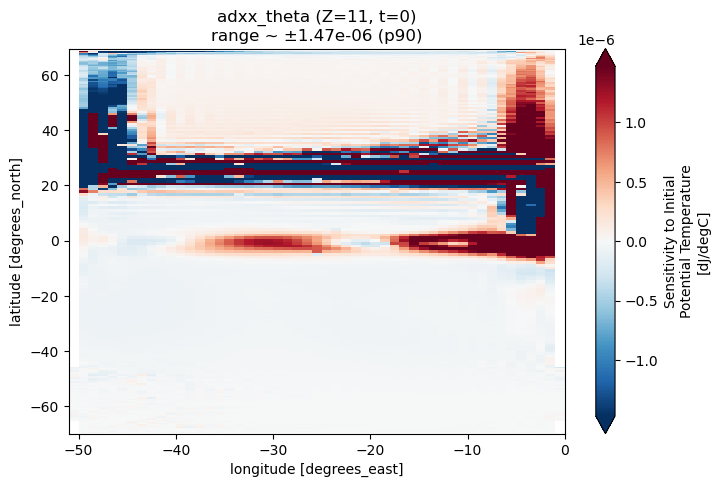

In [21]:
# Select data
t_index = 0
z_index = 11

da = ds_adxx.adxx_theta.isel(time=t_index, Z=z_index)

# Apply ocean mask
da = da.where(ds_adxx.hFacC.isel(Z=z_index) > 0) # hFacC = fraction of open water in a grid cell. 
# Values: 1 → fully ocean, 0 → land, between 0–1 → partial cell (bottom topography)

# Compute robust limits (avoid outliers)
arr = da.values # Converts your xarray.DataArray → 2D NumPy array | Drops coordinates (XC, YC, etc.), Keeps only numerical values
arr = arr[np.isfinite(arr)] # Keeps only real numbers. Removes NaN from masking. arr → 1D array of valid ocean values. arr[mask] implicitly flattens the array.

p = 90  # percentile. If you set p = 90, you are ingnoring the top 10% most extreme values
vmax = np.percentile(np.abs(arr), p) # if p = 90, This returns the value such that 90% of data is below it and 10% are larger (outliers)
vmin = -vmax

# Plot
plt.figure(figsize=(8,5))
da.plot(
    vmin=vmin,
    vmax=vmax,
    cmap='RdBu_r'
)

plt.title(f"adxx_theta (Z={z_index}, t={t_index})\n"
          f"range ~ ±{vmax:.2e} (p{p})")
plt.show()

Plotting adxx_theta


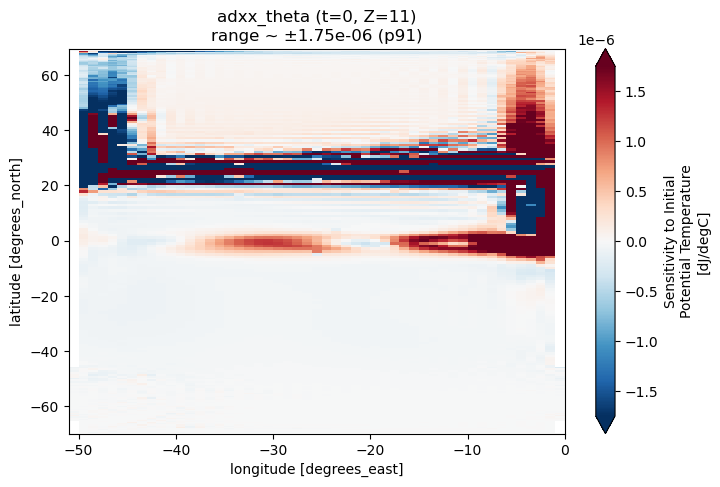

Plotting adxx_salt


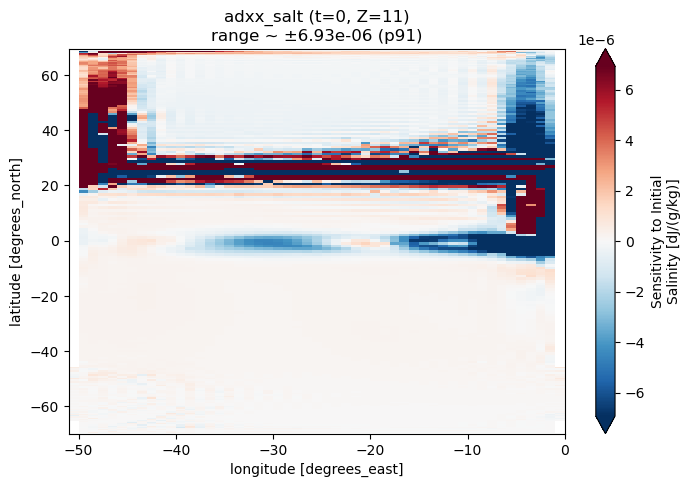

Plotting adxx_diffkr


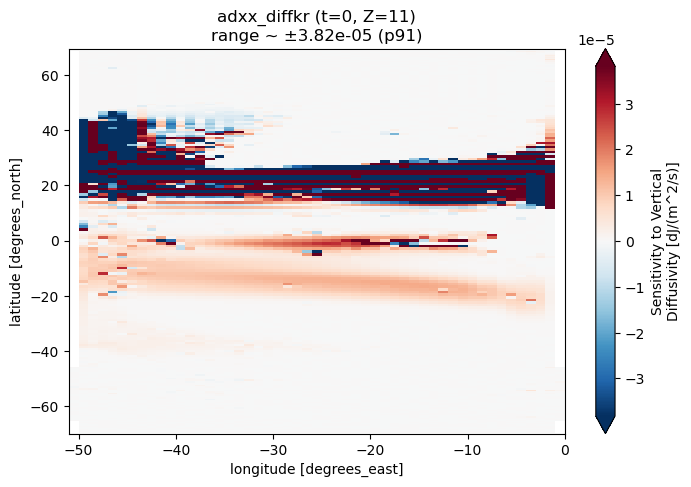

Plotting adxx_fu


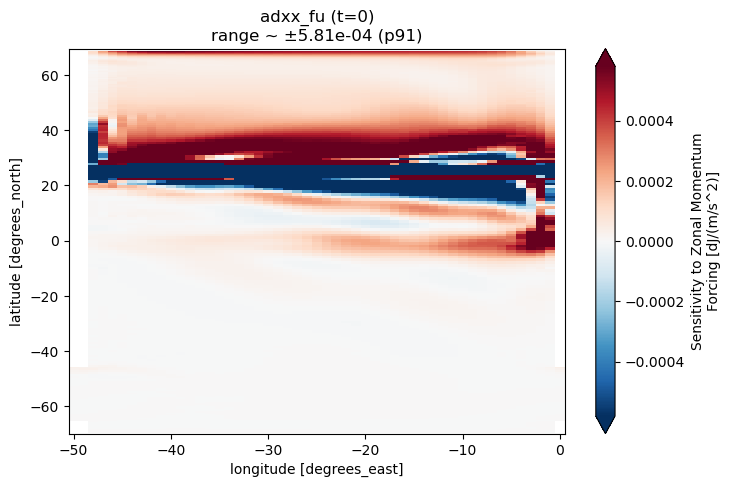

Plotting adxx_fv


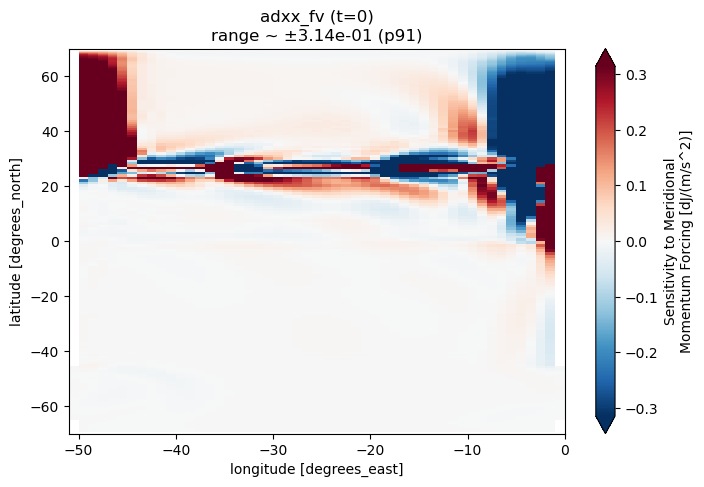

Plotting adxx_qnet


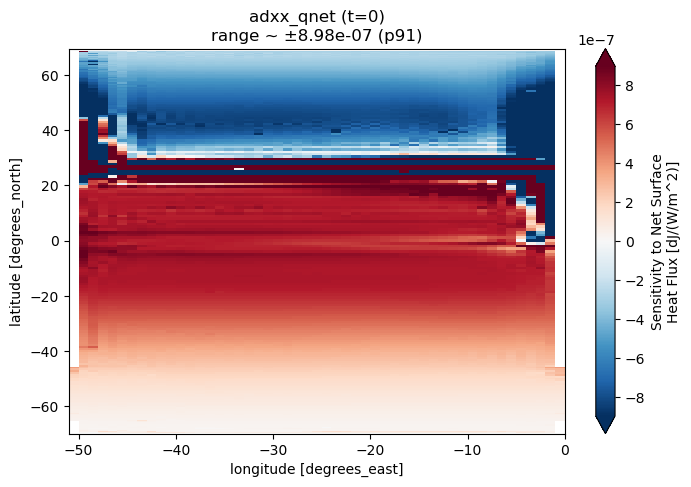

Plotting adxx_qsw


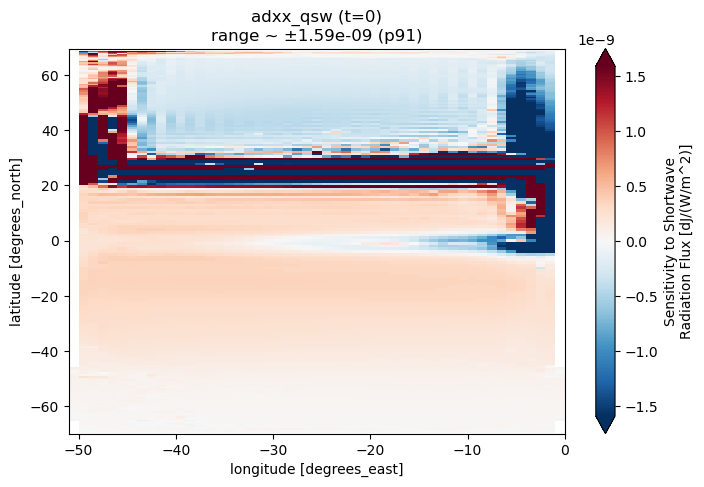

Plotting adxx_empmr


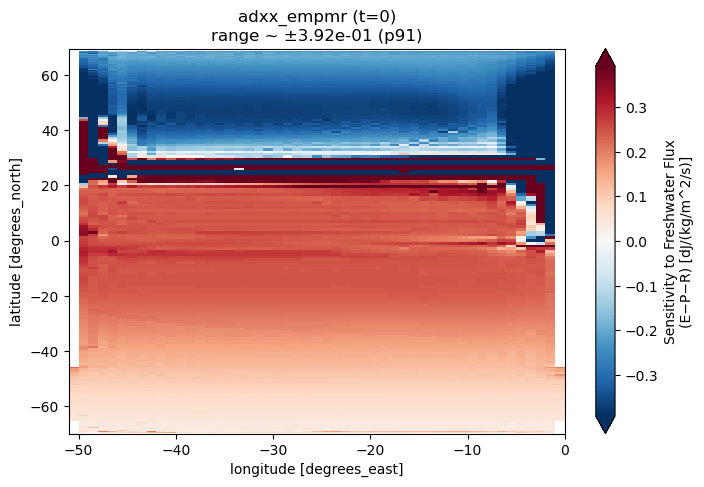

In [22]:
# --- settings ---
t_index = 0
z_index = 11
p = 91  # percentile for robust scaling

# list of variables you want
adxx_vars = [
    "adxx_theta",
    "adxx_salt",
    "adxx_diffkr",
    "adxx_fu",
    "adxx_fv",
    "adxx_qnet",
    "adxx_qsw",
    "adxx_empmr"
]

for var in adxx_vars:

    if var not in ds_adxx:
        print(f"{var} not found, skipping.")
        continue

    print(f"Plotting {var}")

    # --- select data ---
    da = ds_adxx[var]

    # Handle 3D vs 2D variables
    if 'Z' in da.dims:
        da = da.isel(time=t_index, Z=z_index)
    
        if 'XG' in da.dims:
            mask = ds_adxx.hFacW.isel(Z=z_index) > 0
        elif 'YG' in da.dims:
            mask = ds_adxx.hFacS.isel(Z=z_index) > 0
        else:
            mask = ds_adxx.hFacC.isel(Z=z_index) > 0
    
    else:
        da = da.isel(time=t_index)
    
        if 'XG' in da.dims:
            mask = ds_adxx.hFacW.isel(Z=0) > 0
        elif 'YG' in da.dims:
            mask = ds_adxx.hFacS.isel(Z=0) > 0
        else:
            mask = ds_adxx.hFacC.isel(Z=0) > 0

    # apply mask
    da = da.where(mask)

    # --- compute robust scaling ---
    arr = da.values
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        print(f"{var}: ALL NaN, skipping.")
        continue

    vmax = np.percentile(np.abs(arr), p)
    if not np.isfinite(vmax) or vmax == 0:
        vmax = np.nanmax(np.abs(arr))

    vmin = -vmax

    # --- plot ---
    plt.figure(figsize=(8,5))
    da.plot(
        vmin=vmin,
        vmax=vmax,
        cmap='RdBu_r'
    )

    plt.title(f"{var} (t={t_index}"
              + (f", Z={z_index}" if 'Z' in ds_adxx[var].dims else "")
              + f")\nrange ~ ±{vmax:.2e} (p{p})")

    plt.show()

## Animation of ADJ Fields

In [23]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [24]:
def animate_ADJ_3d(var, ds, zlev=11, interval_ms=500, p=95):
    """
    Animate 3D ADJ variable (ADJtheta, ADJsalt, ADJdiffkr)
    at a fixed depth with robust scaling.
    
    Parameters:
    - var : variable name
    - ds : dataset
    - zlev : depth index
    - interval_ms : animation speed
    - p : percentile for robust scaling (default 95)
    """

    # --- check variable ---
    if var not in ds:
        print(f"{var} not in dataset.")
        return

    if var not in ["ADJtheta", "ADJsalt", "ADJdiffkr"]:
        print(f"{var} not in selected 3D variables.")
        return

    da = ds[var].isel(Z=zlev)

    # --- apply ocean mask ---
    if 'hFacC' in ds:
        mask = ds.hFacC.isel(Z=zlev) > 0
        da = da.where(mask)

    A = da.values

    # --- robust symmetric color scale ---
    finite = np.isfinite(A)
    if finite.any():
        vmax = np.percentile(np.abs(A[finite]), p)
        if not np.isfinite(vmax) or vmax == 0:
            vmax = np.nanmax(np.abs(A[finite]))
        if vmax == 0 or not np.isfinite(vmax):
            vmax = 1.0
    else:
        vmax = 1.0

    vmin = -vmax

    print(f"{var}: Z={zlev}, scale=±{vmax:.3e} (p{p})")

    # --- time labels ---
    tcoord = da['time'].values
    def tlabel(i):
        try:
            return str(np.datetime_as_string(tcoord[i], unit='D'))
        except Exception:
            return str(tcoord[i])

    # --- figure setup ---
    fig, ax = plt.subplots(figsize=(10, 5))

    pcm = da.isel(time=0).plot(
        x='XC', y='YC',
        cmap='RdBu_r',
        vmin=vmin, vmax=vmax,
        add_colorbar=False,
        ax=ax
    )

    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(ds[var].attrs.get("long_name", var))

    title = ax.set_title(f"{var} • Z={zlev} • time={tlabel(0)}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    # --- update function ---
    def update(i):
        frame = da.isel(time=i).values

        # IMPORTANT: avoid NaN rendering issues
        frame = np.where(np.isfinite(frame), frame, np.nan)

        pcm.set_array(frame.ravel())
        title.set_text(f"{var} • Z={zlev} • time={tlabel(i)}")

        return pcm, title

    # reverse time (adjoint runs backward)
    frames = list(reversed(range(da.sizes['time'])))

    anim = FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval_ms,
        blit=False
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())

In [34]:
animate_ADJ_3d("ADJtheta", ds_adj, zlev=11, p=99)

ADJtheta: Z=11, scale=±3.464e-05 (p99)


Note about the Above Plot

I had to plot the ADJtheta file in the reverse order of the timestep. This is because, ami forward model er time step use kortesi ADJtheta file k numbering korar jonno. But adjoint runs backward in time. So jokhon plot korbo tokhon seta ke reverse timestep order e plot korte hobe.

"ADJtheta.0000000000.data" data in this file should closely corresponds to the data in the file "adxx_theta.0000000000.data"


Stable untile 3 years, 3 months, and 22 days. After 2051-10-15, the values become very large and blows up

In [26]:
animate_ADJ_3d("ADJsalt", ds_adj, zlev=11, p=65)

ADJsalt: Z=11, scale=±6.109e-07 (p65)


In [27]:
animate_ADJ_3d("ADJdiffkr", ds_adj, zlev=11, p=80)

ADJdiffkr: Z=11, scale=±2.068e-06 (p80)


In [28]:
def animate_ADJ_2d(var, ds, mask_level=0, interval_ms=500, p=95):
    """
    Animate a 2D ADJ field over time.
    Works for XC/YC, XG/YC, XC/YG (all staggered grids).

    Parameters:
    - p : percentile for robust scaling (default 95)
    """

    if var not in ds:
        print(f"{var} not found in dataset.")
        return

    da = ds[var]

    # Apply mask only for tracer grid
    if 'hFacC' in ds and 'XC' in da.dims and 'YC' in da.dims:
        mask = ds.hFacC.isel(Z=mask_level) > 0
        da = da.where(mask)

    A = da.values

    # robust symmetric color scale (UPDATED)
    if np.isfinite(A).any():
        v = np.nanpercentile(np.abs(A), p)
        if v == 0 or not np.isfinite(v):
            v = 1.0
    else:
        v = 1.0

    vmin, vmax = -v, v

    print(f"{var}: shape={A.shape}, scale=±{v:.3e} (p{p})")

    # time helper
    tcoord = da['time'].values
    def tlabel(i):
        try:
            return str(np.datetime_as_string(tcoord[i], unit='D'))
        except Exception:
            return str(tcoord[i])

    # grid-aware
    xcoord = 'XC' if 'XC' in da.dims else 'XG'
    ycoord = 'YC' if 'YC' in da.dims else 'YG'

    # --- figure ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # initial plot
    pcm = da.isel(time=0).plot(
        x=xcoord, y=ycoord,
        cmap='RdBu_r',
        vmin=vmin, vmax=vmax,
        add_colorbar=False,
        ax=ax
    )

    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(da.attrs.get('long_name', var))

    title = ax.set_title(f"{var} • time={tlabel(0)}")

    # update
    def update(i):
        ax.clear()

        da.isel(time=i).plot(
            x=xcoord, y=ycoord,
            cmap='RdBu_r',
            vmin=vmin, vmax=vmax,
            add_colorbar=False,
            ax=ax
        )

        ax.set_title(f"{var} • time={tlabel(i)}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

        return ax,

    frames = list(reversed(range(da.sizes['time'])))

    anim = FuncAnimation(fig, update, frames=frames,
                         interval=interval_ms, blit=False)

    plt.close(fig)
    return HTML(anim.to_jshtml())

In [29]:
animate_ADJ_2d("ADJtaux", ds_adj, p=68)

ADJtaux: shape=(6, 198, 51), scale=±1.099e-07 (p68)


In [30]:
animate_ADJ_2d("ADJtauy", ds_adj, p=68)

ADJtauy: shape=(6, 198, 51), scale=±1.742e-05 (p68)


In [31]:
animate_ADJ_2d("ADJqnet", ds_adj, p=62)

ADJqnet: shape=(6, 198, 51), scale=±4.594e-10 (p62)


In [32]:
animate_ADJ_2d("ADJqsw", ds_adj, p=62)

ADJqsw: shape=(6, 198, 51), scale=±2.289e-13 (p62)


In [33]:
animate_ADJ_2d("ADJempmr", ds_adj, p=62)

ADJempmr: shape=(6, 198, 51), scale=±1.890e-04 (p62)
